In [19]:
import numpy as np
import MAS_library as MASL
from scipy.interpolate import RegularGridInterpolator
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D #only needed for matplotlib 3D projections
import readgadget
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.stats import skew
import smoothing_library as SL



In [20]:
#data extraction
#---------------


snap_init = "./output/snap_000.hdf5"
snap_final = "./output/snap_192.hdf5"

all_ids_zip_path = "all_ParticleIDs_halo_mapped.npz"

box_size = readgadget.header(snap_final).boxsize #Mpc/h
halo_particle_ids = np.load(all_ids_zip_path)['halo_1']
ptype = [1]


#initial snapshot data

#raw positions
all_init_positions = readgadget.read_block(snap_init, "POS ", ptype)
all_init_ids = readgadget.read_block(snap_init, "ID  ", ptype)

#look up only halo ids
id_to_index = {pid:idx for idx,pid in enumerate(all_init_ids)}
halo_init_indices = [id_to_index[pid] for pid in halo_particle_ids]
halo_init_positions = all_init_positions[halo_init_indices]

#centering
init_center_x = np.median(halo_init_positions[:, 0])
init_center_y = np.median(halo_init_positions[:, 1])
init_center_z = np.median(halo_init_positions[:, 2])

dx_i = halo_init_positions[:, 0] - init_center_x
dy_i = halo_init_positions[:, 1] - init_center_y
dz_i = halo_init_positions[:, 2] - init_center_z

x_init = dx_i - box_size*np.round(dx_i/box_size)
y_init = dy_i - box_size*np.round(dy_i/box_size)
z_init = dz_i - box_size*np.round(dz_i/box_size)

#final snapshot data 

#raw positions
all_final_positions = readgadget.read_block(snap_final, "POS ", ptype)
all_final_ids        = readgadget.read_block(snap_final, "ID  ", ptype)

#id mapping
final_id_map = {pid: idx for idx, pid in enumerate(all_final_ids)}
halo_final_indices  = [final_id_map[pid] for pid in halo_particle_ids]
halo_final_positions = all_final_positions[halo_final_indices]

#centering
center_x = np.median(halo_final_positions[:, 0])
center_y = np.median(halo_final_positions[:, 1])
center_z = np.median(halo_final_positions[:, 2])

dx_f = halo_final_positions[:, 0] - center_x
dy_f = halo_final_positions[:, 1] - center_y
dz_f = halo_final_positions[:, 2] - center_z

#this needs to account for periodic wrapping
x_final = dx_f - box_size*np.round(dx_f/box_size)
y_final = dy_f - box_size*np.round(dy_f/box_size)
z_final = dz_f - box_size*np.round(dz_f/box_size)

print(box_size)

50.0


In [21]:
all_final_positions = readgadget.read_block(snap_final, "POS ", ptype)
all_final_ids        = readgadget.read_block(snap_final, "ID  ", ptype)

final_id_map = {pid: idx for idx, pid in enumerate(all_final_ids)}
halo_final_indices  = [final_id_map[pid] for pid in halo_particle_ids]
halo_final_positions = all_final_positions[halo_final_indices]

center_x = np.median(halo_final_positions[:, 0])
center_y = np.median(halo_final_positions[:, 1])
center_z = np.median(halo_final_positions[:, 2])

x_final = halo_final_positions[:, 0] - center_x
y_final = halo_final_positions[:, 1] - center_y
z_final = halo_final_positions[:, 2] - center_z


In [22]:
#Density field
#-------------
grid = 256
density = np.zeros((grid,grid,grid), dtype=np.float32)
MASL.MA(all_init_positions, density, box_size, MAS='CIC', verbose=True)

delta = density
delta /= np.mean(density)
delta -= 1 #3D array

#i think this finds out the cell boundaries?
grid_edges = np.linspace(0.0, box_size, grid+1)
edges = [grid_edges, grid_edges, grid_edges]
#no clue how it's doing it but pretty sure this divides the cells in half and stores the centres
x_cell_centers = 0.5 * (edges[0][:-1] + edges[0][1:])
y_cell_centers = 0.5 * (edges[1][:-1] + edges[1][1:])
z_cell_centers = 0.5 * (edges[2][:-1] + edges[2][1:])

#interpolation of overdensity value to each particle
rgi = RegularGridInterpolator((x_cell_centers, y_cell_centers, z_cell_centers),
                                 delta, bounds_error = False, fill_value = 0.0)
all_particle_overdensity = rgi(all_init_positions)
halo_particle_overdensity = rgi(halo_init_positions) #1D array


Using CIC mass assignment scheme
Time taken = 0.042 seconds



In [23]:
#SMOOTHING the overdensity field
R = 3.5 #smoothing scale in Mpc/h
Filter = 'Gaussian'
threads = 4

#this computes the FFT of the filter (?)
W_k = SL.FT_filter(box_size, R, grid, Filter, threads)

delta_smoothed = SL.field_smoothing(delta, W_k, threads)


#NEEDS INTERPOLATION 
rgi_s = RegularGridInterpolator((x_cell_centers, y_cell_centers, z_cell_centers),
                                 delta_smoothed, bounds_error = False, fill_value = 0.0)
all_particle_smpoothed_overdensity = rgi_s(all_init_positions)
halo_particle_smoothed_overdensity = rgi_s(halo_init_positions) #1D array

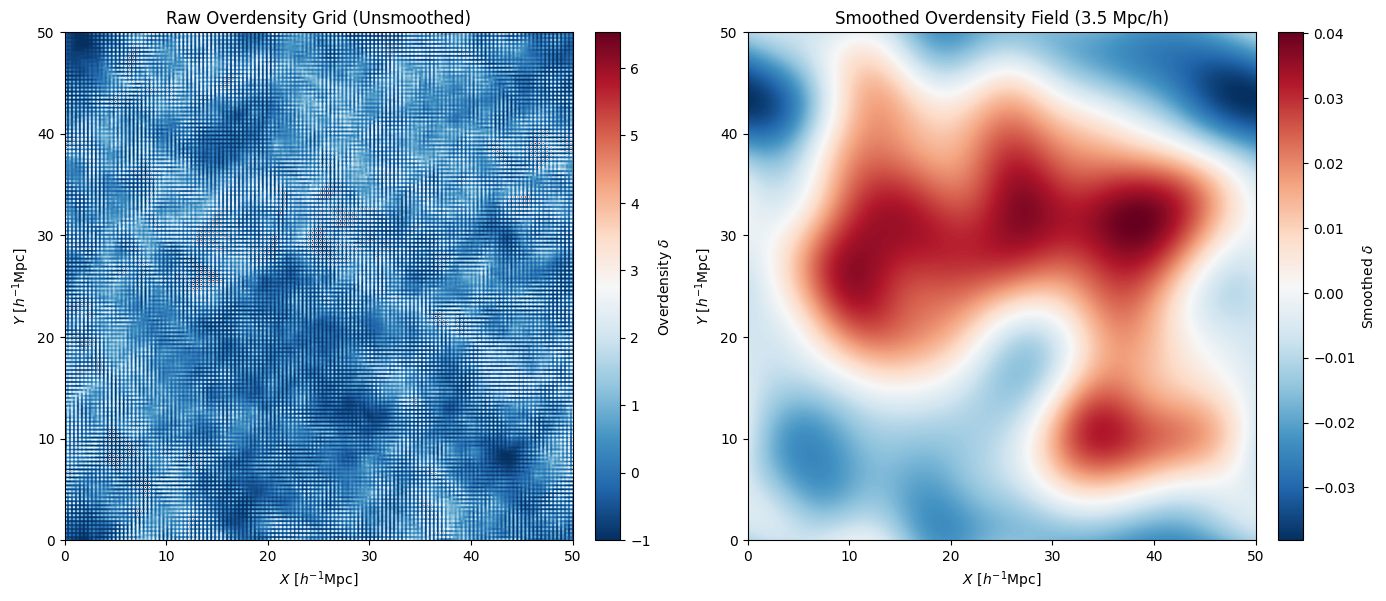

In [24]:
#density field 2d slice

#middle slice along the Z-axis
mid_idx = delta_smoothed.shape[0] // 2

slice_raw = delta[:, :, mid_idx]      # Your raw unsmoothed grid
slice_smooth = delta_smoothed[:, :, mid_idx]  # Your smoothed array

#subplot 
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# non smoothed
im0 = axes[0].imshow(
    slice_raw,
    cmap="RdBu_r",
    origin="lower",
    extent=[0, 50, 0, 50]  # Maps pixels to 50 Mpc/h physical box size
)
axes[0].set_title("Raw Overdensity Grid (Unsmoothed)")
axes[0].set_xlabel(r"$X\ [h^{-1}\text{Mpc}]$")
axes[0].set_ylabel(r"$Y\ [h^{-1}\text{Mpc}]$")
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04, label=r"Overdensity $\delta$")

# Smoothed
im1 = axes[1].imshow(
    slice_smooth,
    cmap="RdBu_r",
    origin="lower",
    extent=[0, 50, 0, 50]
)
axes[1].set_title("Smoothed Overdensity Field (3.5 Mpc/h)")
axes[1].set_xlabel(r"$X\ [h^{-1}\text{Mpc}]$")
axes[1].set_ylabel(r"$Y\ [h^{-1}\text{Mpc}]$")
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04, label=r"Smoothed $\delta$")

plt.tight_layout()
plt.show()

In [25]:
#painting by smoothed field
higher = 100
lower = 0
vmin, vmax = np.percentile(halo_particle_smoothed_overdensity, [lower, higher])  #high percentile cut off means more particles coloured with the intermediate values

fig = make_subplots(
    rows=1, cols=2,
    specs=[[{"type": "scene"}, {"type": "scene"}]],
    subplot_titles=("z=63 (smoothed initial overdensity distribution)",
                     "z=0 (final particle distribution painted with smoothed initial δ)")
)

fig.add_trace(
    go.Scatter3d(
        x=x_init, y=y_init, z=z_init,
        mode="markers",
        marker=dict(                        #this does a data clipping similar to np.clip while rendering
            size=2,
            color=halo_particle_smoothed_overdensity,
            colorscale="RdBu_r",
            cmin=vmin, cmax=vmax,
            showscale=False,
            opacity=0.25
        ),
        hovertext=[
            f"PID: {pid}<br>δ (z=63): {d:.3f}"
            for pid, d in zip(halo_particle_ids, halo_particle_smoothed_overdensity)
        ],
        hoverinfo="text"
    ),
    row=1, col=1
)

fig.add_trace(
    go.Scatter3d(
        x=x_final, y=y_final, z=z_final,
        mode="markers",
        marker=dict(
            size=2,
            color=halo_particle_smoothed_overdensity,
            colorscale="RdBu_r",
            cmin=vmin, cmax=vmax,
            colorbar=dict(
                title=dict(text="Smoothed Initial Overdensity δ (z=63)", side="right"),
                thickness=15
            ),
            showscale=True,
            opacity=0.25
        ),
        hovertext=[
            f"PID: {pid}<br>δ (z=63): {d:.3f}"
            for pid, d in zip(halo_particle_ids, halo_particle_smoothed_overdensity)
        ],
        hoverinfo="text"
    ),
    row=1, col=2
)

fig.update_scenes(
    xaxis=dict(title="X (Relative Mpc/h)", backgroundcolor="light gray", gridcolor="white"),
    yaxis=dict(title="Y (Relative Mpc/h)", backgroundcolor="light gray", gridcolor="white"),
    zaxis=dict(title="Z (Relative Mpc/h)", backgroundcolor="light gray", gridcolor="white"),
    aspectmode='data'  # Maintains 1:1:1 aspect ratio so the halo doesn't warp
        
)

fig.update_layout(
    title="Spatial Evolution of Smoothed Initial Overdensity (clipped)",
    margin=dict(l=0, r=0, b=0, t=50),
)

particles_in_higher_percentile = np.sum(halo_particle_smoothed_overdensity>=vmax)
print(f"No. of particles in the {higher}th percentile = {particles_in_higher_percentile}")
print(np.percentile(halo_particle_smoothed_overdensity,[0,99,99.5,99.8,99.9,99.95,99.98,99.99,100]))
fig.show()

#fig.write_html("Smoothed_overdensity_G.html")


No. of particles in the 100th percentile = 1
[-0.0137615   0.03739124  0.03790273  0.038341    0.03856865  0.03870209
  0.03882959  0.03888252  0.03905973]


no. of overdensity values = 34445


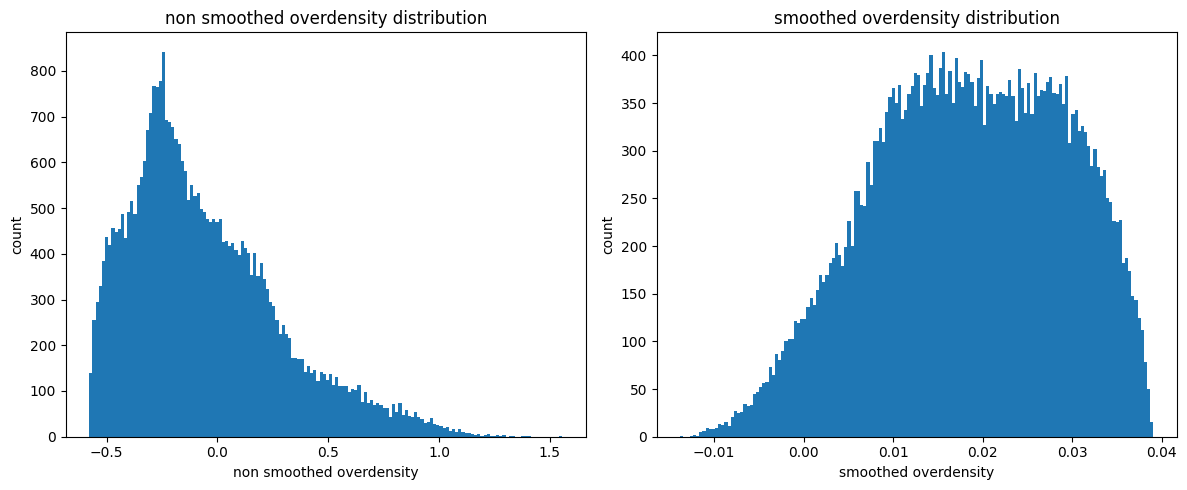

In [26]:
#histogram
bins = 150
print(f"no. of overdensity values = {len(halo_particle_smoothed_overdensity)}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))


axes[1].hist(halo_particle_smoothed_overdensity, bins=bins)
axes[1].set_xlabel("smoothed overdensity")
axes[1].set_ylabel("count")
axes[1].set_title("smoothed overdensity distribution")

axes[0].hist(halo_particle_overdensity, bins=bins)
axes[0].set_xlabel("non smoothed overdensity")
axes[0].set_ylabel("count")
axes[0].set_title("non smoothed overdensity distribution")

plt.tight_layout()
plt.show()

In [33]:
import os
import glob
import numpy as np
import readgadget
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from matplotlib.colors import Normalize
from scipy.interpolate import RegularGridInterpolator
import MAS_library as MASL
import imageio.v2 as imageio

# =====================================================================
# CONFIG
# =====================================================================
OUTPUT_DIR   = "./output"
ref_snap     = 0                       # snapshot that DEFINES each particle's origin colour
n_snapshots  = 193                     # snap_000 ... snap_192
ptype        = [1]                     # dark matter
grid         = 256
halo_npz_path = "all_ParticleIDs_halo_mapped.npz"

frame_dir  = "smoothed_frames"
video_path = "smoothed_evolution.mp4"
fps        = 15

os.makedirs(frame_dir, exist_ok=True)

def snap_path(n):
    return f"{OUTPUT_DIR}/snap_{n:03d}.hdf5"

def match_ids(all_ids, target_ids):
    """Vectorized ID -> index lookup (fast for full-snapshot particle counts)."""
    order      = np.argsort(all_ids)
    ids_sorted = all_ids[order]
    loc        = np.searchsorted(ids_sorted, target_ids)
    idx        = order[loc]
    assert np.all(all_ids[idx] == target_ids), "Some target IDs not found in snapshot!"
    return idx

# =====================================================================
# STEP 1: reference snapshot -> fixed per-particle "origin" overdensity
# =====================================================================
print(f"Reading reference snapshot {ref_snap} (defines fixed particle colours)...")
boxsize       = readgadget.header(snap_path(ref_snap)).boxsize
ref_positions = readgadget.read_block(snap_path(ref_snap), "POS ", ptype)
ref_ids       = readgadget.read_block(snap_path(ref_snap), "ID  ", ptype)

halo_data         = np.load(halo_npz_path)
halo_particle_ids = halo_data["halo_1"]

halo_ref_indices   = match_ids(ref_ids, halo_particle_ids)
halo_ref_positions = ref_positions[halo_ref_indices]


norm = Normalize(vmin=vmin, vmax=vmax)
draw_order = np.argsort(halo_particle_smoothed_overdensity)   # densest particles drawn last (on top) every frame

# Fixed spatial box size for every frame, so the animation doesn't rescale
# jarringly between frames - use the initial protohalo spread
# ------------------------------------------------------------------
# ------------------------------------------------------------------
# Precompute the ACTUAL halo extent at every snapshot first, so we
# know the real per-frame span rather than assuming a smooth
# interpolation between the first and last frame's spans
# ------------------------------------------------------------------
print("Precomputing halo extent at every snapshot...")
spans = np.zeros(n_snapshots)

for snap in range(n_snapshots):
    positions = readgadget.read_block(snap_path(snap), "POS ", ptype)
    ids       = readgadget.read_block(snap_path(snap), "ID  ", ptype)
    halo_indices = match_ids(ids, halo_particle_ids)
    halo_pos     = positions[halo_indices]
    spans[snap]  = np.ptp(halo_pos, axis=0).max() / 2
    print(f"  snap {snap}: span = {spans[snap]:.4f}", end='\r')

# Smooth the span sequence slightly so the zoom doesn't jitter frame-to-frame
# from small fluctuations, while still tracking the real expand/contract shape
#from scipy.ndimage import uniform_filter1d
#spans_smoothed = uniform_filter1d(spans, size=5, mode='nearest')

spans_smoothed = spans

# Padding factor - gives breathing room so particles near the edge
# of the halo aren't clipped right at the axis boundary
padding = 1.05
spans_padded = spans_smoothed * padding

print(f"\nSpan range across all snapshots: {spans_padded.min():.4f} to {spans_padded.max():.4f}")

# =====================================================================
# STEP 2: loop over every snapshot, render + save each frame as a PNG
# =====================================================================
fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(1, 1, 1, projection='3d')

for snap in range(n_snapshots):
    print(f"Rendering snapshot {snap+1}/{n_snapshots}...", end='\r')

    positions = readgadget.read_block(snap_path(snap), "POS ", ptype)
    ids       = readgadget.read_block(snap_path(snap), "ID  ", ptype)
    redshift  = readgadget.header(snap_path(snap)).redshift

    halo_indices   = match_ids(ids, halo_particle_ids)
    halo_positions = positions[halo_indices]

    center = np.median(halo_positions, axis=0)
    x, y, z = (halo_positions - center).T

    ax.clear()
    ax.scatter(
        x[draw_order], y[draw_order], z[draw_order],
        c=halo_particle_smoothed_overdensity[draw_order], cmap='RdBu_r', norm=norm,
        s=4, alpha=0.85, linewidths=0
    )
    ax.set_title(f"Halo_1 — Z = {redshift:4.2f}")
    ax.set_xlabel("X [Mpc/h]")
    ax.set_ylabel("Y [Mpc/h]")
    ax.set_zlabel("Z [Mpc/h]")

    span = spans_padded[snap]   # actual, padded extent for THIS specific snapshot
    ax.set_xlim(-span, span)
    ax.set_ylim(-span, span)
    ax.set_zlim(-span, span)
    ax.set_box_aspect([1, 1, 1])

    azim = 45 + (360 * snap / n_snapshots)
    ax.view_init(elev=20, azim=azim)

    frame_path = os.path.join(frame_dir, f"frame_{snap:03d}.png")
    fig.savefig(frame_path, dpi=150)

plt.close(fig)
print(f"\nAll {n_snapshots} frames saved to '{frame_dir}/'.")

# =====================================================================
# STEP 3: stitch the saved frames into a video with imageio
# =====================================================================
print("Assembling video from saved frames...")
frame_files = sorted(glob.glob(os.path.join(frame_dir, "frame_*.png")))
assert len(frame_files) == n_snapshots, \
    f"Expected {n_snapshots} frames, found {len(frame_files)} - check for missing snapshots."

with imageio.get_writer(video_path, fps=fps) as writer:
    for f in frame_files:
        writer.append_data(imageio.imread(f))

print(f"Done. Video saved to '{video_path}'.")


Reading reference snapshot 0 (defines fixed particle colours)...
Precomputing halo extent at every snapshot...
  snap 192: span = 1.3969
Span range across all snapshots: 1.4667 to 11.5327


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1050, 1050) to (1056, 1056) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).



All 193 frames saved to 'smoothed_frames/'.
Assembling video from saved frames...
Done. Video saved to 'smoothed_evolution.mp4'.
